# 04 — Fixed-IF Segmentation Pilot

Load one FOV per condition from `cleaved_tmem_pld3_260821` (d7), run Cellpose
nuclear segmentation on DAPI, overlay masks. Goal: confirm segmentation quality
before building per-cell feature extraction.

Dataset: 72 ND2, fixed 4-ch IF (MAP2/488, LAMP1/640, cleaved TMEM106B/561, DAPI/405),
60× water, 0.108 µm/px, z-stacks 6–16 slices.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries

from tmem_align.analysis.if_spatial import (
    load_fov, segment_nuclei,
    CH_DAPI, CH_MAP2, CH_TMEM, CH_LAMP1,
)

DATA = Path("/Users/pmihack/claire/tmem_2026/data/cleaved_tmem_pld3_260821/d7")
REPORT = Path("../reports/if_segmentation_pilot")
REPORT.mkdir(parents=True, exist_ok=True)

In [2]:
# One representative FOV per condition (F1 of first well in each group)
fov_paths = {
    "TMEM_KO":     DATA / "TMEM_KO/TMEMKO_Plate1_d7_TMEM561LAMP1640MAP2488DAPI405_C8_F1.nd2",
    "PLD_Control": DATA / "Z59_PLD_Control/PLD3Control_Plate1_d7_TMEM561LAMP1640MAP2488DAPI405_C17_F1.nd2",
    "PLD_TMEMki":  DATA / "Z60_PLD_TMEMki/PLD3TMEM106B_Plate1_d7_TMEM561LAMP1640MAP2488DAPI405_C20_F1.nd2",
}

channels = {}
for cond, path in fov_paths.items():
    print(f"Loading {cond}...")
    channels[cond] = load_fov(path)
    print(f"  channels: {list(channels[cond].keys())}")
    for ch_name, arr in channels[cond].items():
        print(f"    {ch_name}: shape={arr.shape} dtype={arr.dtype}")

Loading TMEM_KO...
  channels: ['488nm', '640nm', '561nm', '405nm']
    488nm: shape=(2048, 2048) dtype=uint16
    640nm: shape=(2048, 2048) dtype=uint16
    561nm: shape=(2048, 2048) dtype=uint16
    405nm: shape=(2048, 2048) dtype=uint16
Loading PLD_Control...
  channels: ['488nm', '640nm', '561nm', '405nm']
    488nm: shape=(2048, 2048) dtype=uint16
    640nm: shape=(2048, 2048) dtype=uint16
    561nm: shape=(2048, 2048) dtype=uint16
    405nm: shape=(2048, 2048) dtype=uint16
Loading PLD_TMEMki...
  channels: ['488nm', '640nm', '561nm', '405nm']
    488nm: shape=(2048, 2048) dtype=uint16
    640nm: shape=(2048, 2048) dtype=uint16
    561nm: shape=(2048, 2048) dtype=uint16
    405nm: shape=(2048, 2048) dtype=uint16


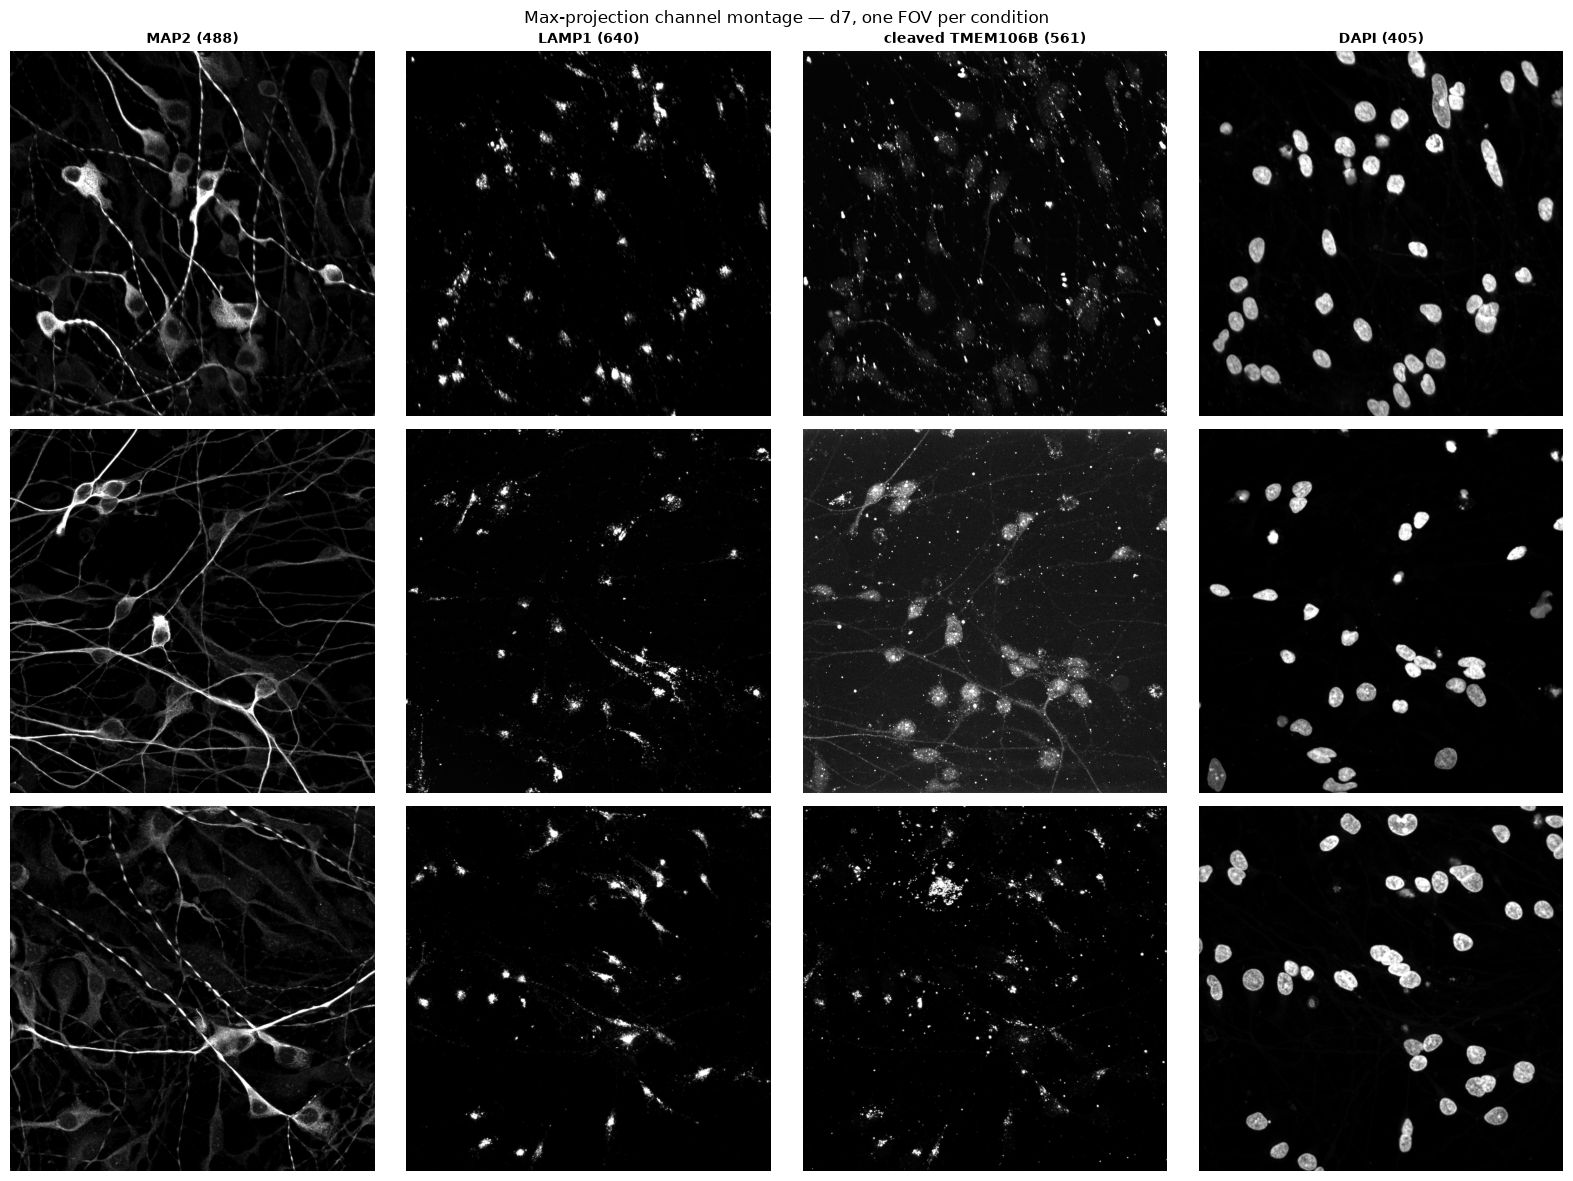

Saved channel_montage.png


In [3]:
# 4-channel montage: rows = conditions, cols = channels
ch_order  = [CH_MAP2,      CH_LAMP1,       CH_TMEM,                CH_DAPI]
ch_labels = ["MAP2 (488)", "LAMP1 (640)",  "cleaved TMEM106B (561)", "DAPI (405)"]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for row, (cond, chs) in enumerate(channels.items()):
    for col, (ch, label) in enumerate(zip(ch_order, ch_labels)):
        img = chs[ch].astype(np.float32)
        lo, hi = np.percentile(img, [1, 99.5])
        display = np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)
        axes[row, col].imshow(display, cmap="gray")
        if row == 0:
            axes[row, col].set_title(label, fontsize=10, fontweight="bold")
        if col == 0:
            axes[row, col].set_ylabel(cond, fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Max-projection channel montage — d7, one FOV per condition", fontsize=12)
plt.tight_layout()
plt.savefig(REPORT / "channel_montage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved channel_montage.png")

In [4]:
# Cellpose nuclear segmentation on DAPI
# diameter=111 px ≈ 12 µm nucleus at 0.108 µm/px; pass None to auto-detect (slower)
masks = {}
for cond, chs in channels.items():
    print(f"Segmenting {cond}...")
    masks[cond] = segment_nuclei(chs[CH_DAPI])
    n_cells = int(masks[cond].max())
    print(f"  {n_cells} nuclei detected")

Segmenting TMEM_KO...


/Users/pmihack/claire/tmem_2026/tmem-neuron-aligner/.venv/lib/python3.13/site-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:823.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


  47 nuclei detected
Segmenting PLD_Control...


  39 nuclei detected
Segmenting PLD_TMEMki...


  45 nuclei detected


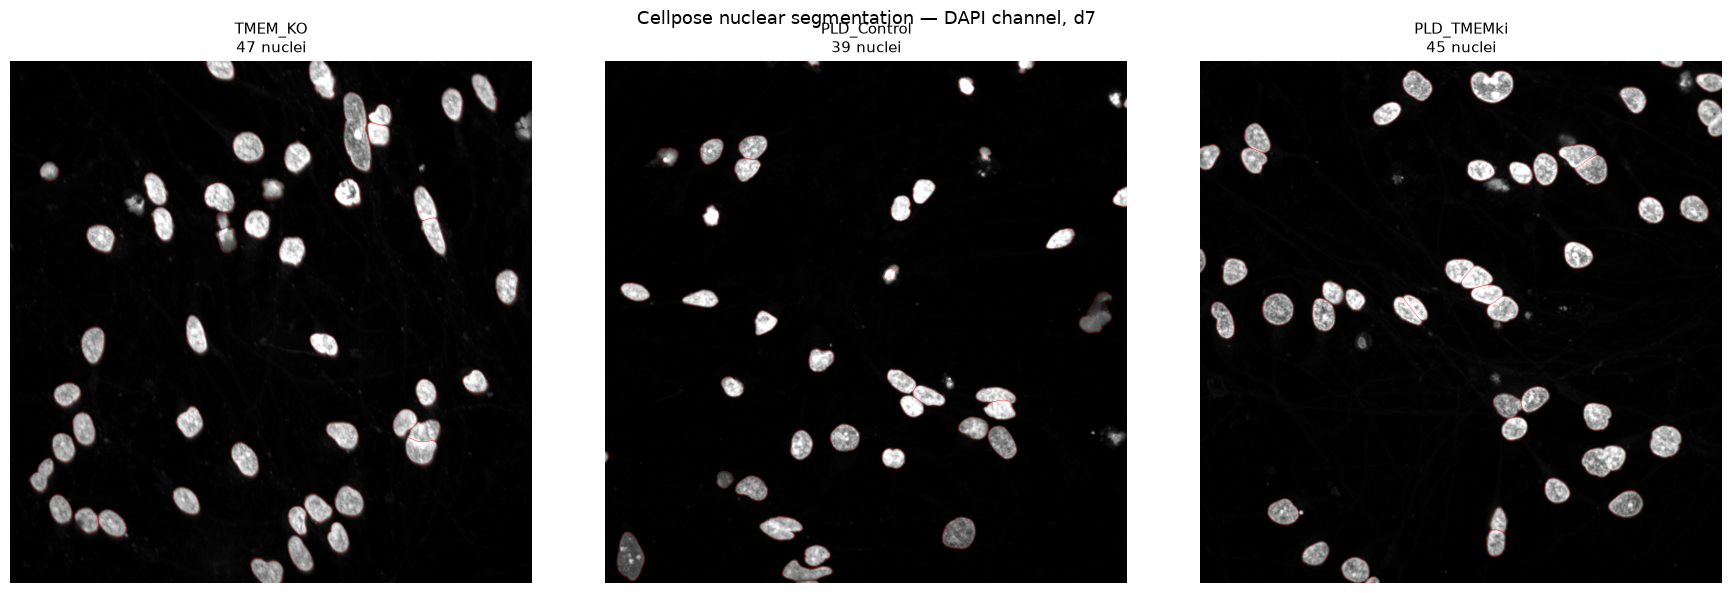

Saved nuclei_overlay.png


In [5]:
# Overlay: nuclear mask boundaries on DAPI (red outlines)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (cond, chs) in zip(axes, channels.items()):
    dapi = chs[CH_DAPI].astype(np.float32)
    lo, hi = np.percentile(dapi, [1, 99.5])
    gray = np.clip((dapi - lo) / (hi - lo + 1e-6), 0, 1)
    rgb = np.stack([gray, gray, gray], axis=-1)
    bounds = find_boundaries(masks[cond], mode="outer")
    rgb[bounds] = [1, 0, 0]
    ax.imshow(rgb)
    ax.set_title(f"{cond}\n{int(masks[cond].max())} nuclei", fontsize=11)
    ax.axis("off")

plt.suptitle("Cellpose nuclear segmentation — DAPI channel, d7", fontsize=13)
plt.tight_layout()
plt.savefig(REPORT / "nuclei_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved nuclei_overlay.png")

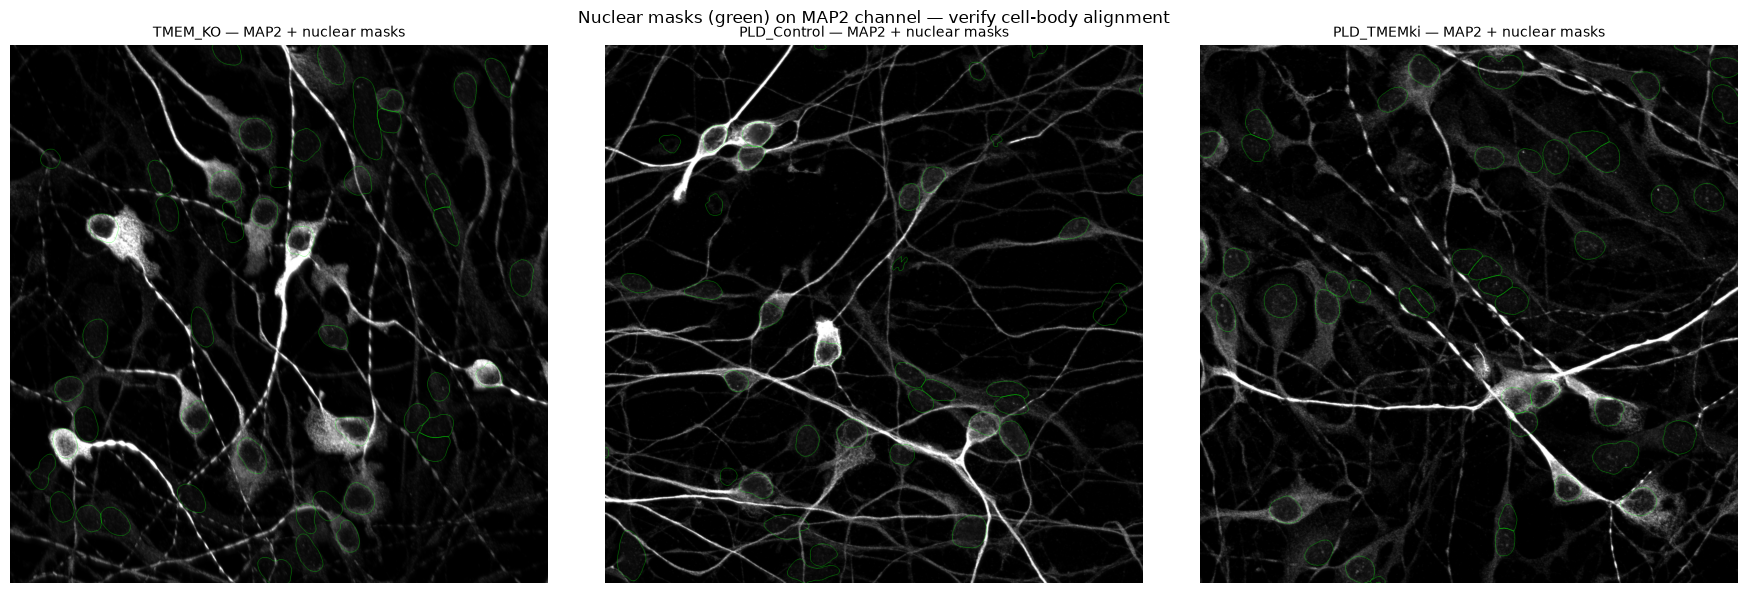

Saved map2_nuclei_overlay.png


In [6]:
# Overlay: MAP2 channel with nuclear masks — check MAP2 vs nucleus alignment
# (MAP2 = neuronal cytoskeleton; nuclei should sit inside MAP2+ cell bodies)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (cond, chs) in zip(axes, channels.items()):
    map2 = chs[CH_MAP2].astype(np.float32)
    lo, hi = np.percentile(map2, [1, 99.5])
    gray = np.clip((map2 - lo) / (hi - lo + 1e-6), 0, 1)
    rgb = np.stack([gray, gray, gray], axis=-1)
    bounds = find_boundaries(masks[cond], mode="outer")
    rgb[bounds] = [0, 1, 0]  # green outlines on MAP2
    ax.imshow(rgb)
    ax.set_title(f"{cond} — MAP2 + nuclear masks", fontsize=10)
    ax.axis("off")

plt.suptitle("Nuclear masks (green) on MAP2 channel — verify cell-body alignment", fontsize=12)
plt.tight_layout()
plt.savefig(REPORT / "map2_nuclei_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved map2_nuclei_overlay.png")

## Cell-body segmentation on MAP2 (cytoplasmic)

Above we segmented **DAPI (nuclear)**. MAP2 is a **cytoplasmic/cytoskeletal**
neuronal marker, so running Cellpose-SAM directly on MAP2 gives **cell-body**
outlines instead of nuclei. Same `cpsam` model, run on the 488 channel with a
larger diameter (soma > nucleus). Compare these outlines to the nuclear masks
above — cell bodies should enclose the nuclei.

In [7]:
# Cellpose-SAM cell-body segmentation on MAP2 (cytoplasmic channel)
# Same cpsam model as the nuclei step; diameter=None lets it auto-detect the
# soma scale (cell bodies are larger and more variable than nuclei).
map2_masks = {}
for cond, chs in channels.items():
    print(f"Segmenting MAP2 cell bodies — {cond}...")
    map2_masks[cond] = segment_nuclei(chs[CH_MAP2], diameter=None)
    print(f"  {int(map2_masks[cond].max())} cell bodies detected")

Segmenting MAP2 cell bodies — TMEM_KO...


  47 cell bodies detected
Segmenting MAP2 cell bodies — PLD_Control...


  54 cell bodies detected
Segmenting MAP2 cell bodies — PLD_TMEMki...


  87 cell bodies detected


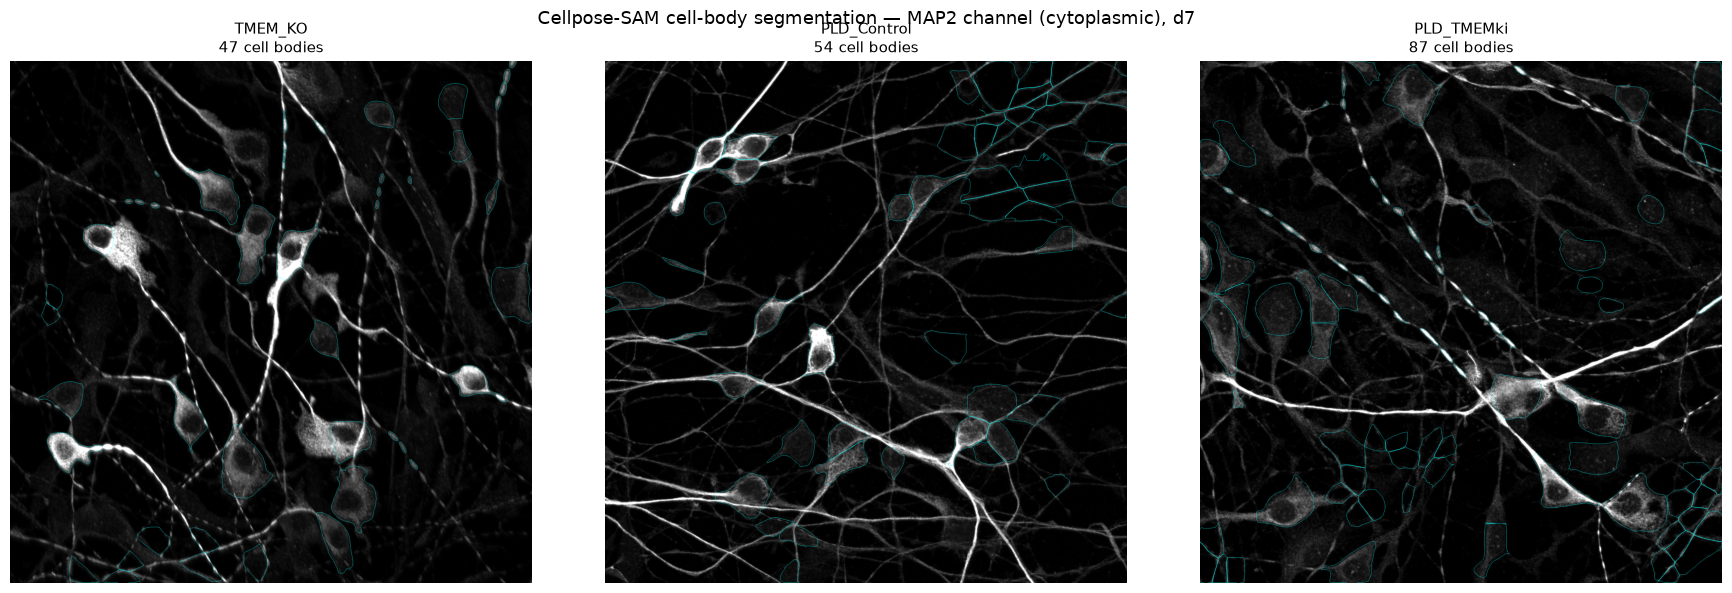

Saved map2_cellbody_overlay.png


In [8]:
# Overlay: MAP2 cell-body mask boundaries on the MAP2 channel (cyan outlines)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (cond, chs) in zip(axes, channels.items()):
    map2 = chs[CH_MAP2].astype(np.float32)
    lo, hi = np.percentile(map2, [1, 99.5])
    gray = np.clip((map2 - lo) / (hi - lo + 1e-6), 0, 1)
    rgb = np.stack([gray, gray, gray], axis=-1)
    bounds = find_boundaries(map2_masks[cond], mode="outer")
    rgb[bounds] = [0, 1, 1]  # cyan outlines
    ax.imshow(rgb)
    ax.set_title(f"{cond}\n{int(map2_masks[cond].max())} cell bodies", fontsize=11)
    ax.axis("off")

plt.suptitle("Cellpose-SAM cell-body segmentation — MAP2 channel (cytoplasmic), d7", fontsize=13)
plt.tight_layout()
plt.savefig(REPORT / "map2_cellbody_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved map2_cellbody_overlay.png")

## Seeded cell-body expansion (DAPI nuclei → MAP2 foreground)

Direct MAP2 segmentation above missed real somata and tessellated the neurite
mesh. Instead: reuse the clean DAPI nuclei as seeds and grow each one outward
by watershed, clipped to a MAP2 foreground mask and a max radius. One cell body
per real nucleus — no missed somata, no fake background cells.

Two knobs to set from the overlay: `close_radius` (MAP2 mask fill) and
`max_distance` (soma-only vs soma+proximal, px at 0.108 µm/px).

In [9]:
from tmem_align.analysis.if_spatial import expand_to_cell_bodies

# Seed from the DAPI nuclei masks (from the nuclei step above), grow into MAP2.
# Defaults: max_distance=110px (~12µm soma), interior holes filled → solid bodies.
cell_bodies = {}
for cond, chs in channels.items():
    cell_bodies[cond] = expand_to_cell_bodies(masks[cond], chs[CH_MAP2])
    print(f"{cond}: {int(masks[cond].max())} nuclei → {int(cell_bodies[cond].max())} cell bodies")

TMEM_KO: 47 nuclei → 47 cell bodies


PLD_Control: 39 nuclei → 39 cell bodies


PLD_TMEMki: 45 nuclei → 45 cell bodies


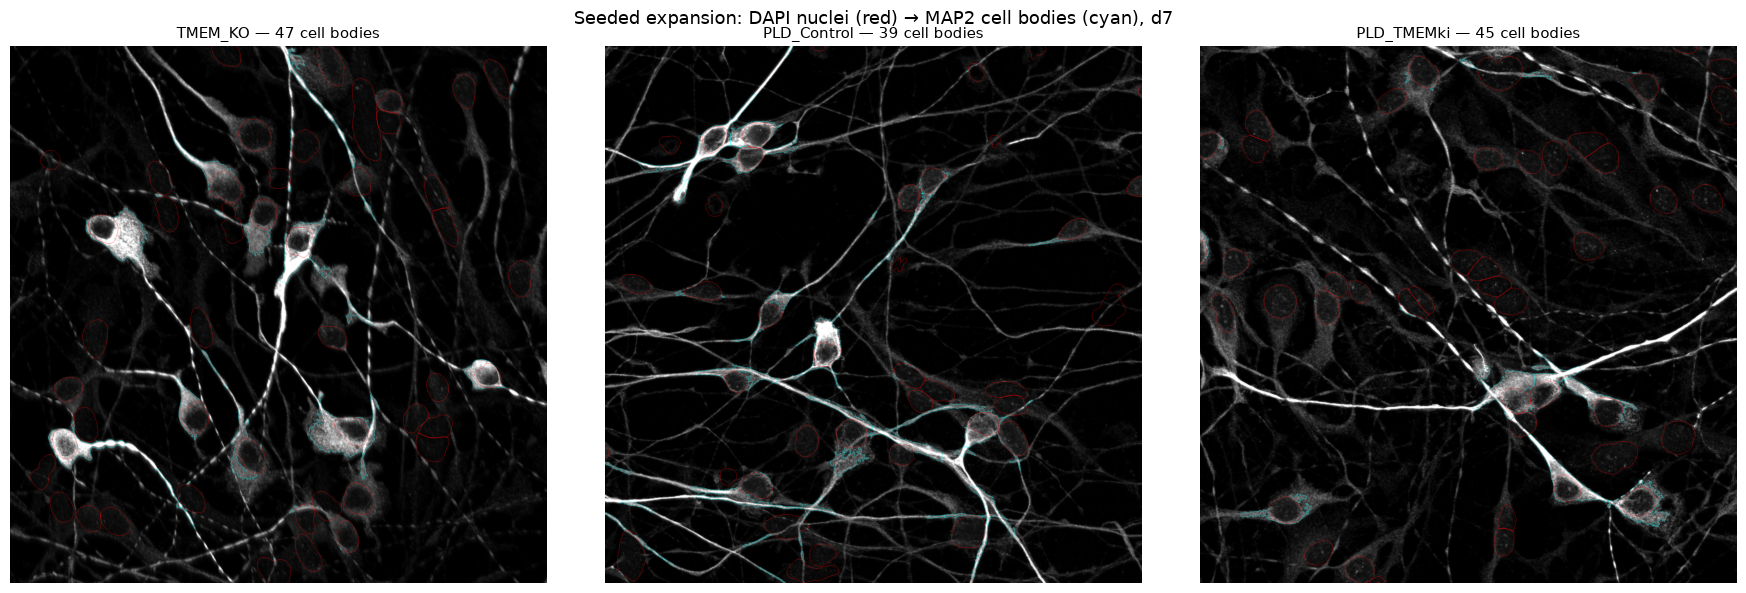

Saved map2_seeded_cellbody_overlay.png


In [10]:
# Overlay: seeded cell-body outlines (cyan) + nucleus outlines (red) on MAP2
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (cond, chs) in zip(axes, channels.items()):
    map2 = chs[CH_MAP2].astype(np.float32)
    lo, hi = np.percentile(map2, [1, 99.5])
    gray = np.clip((map2 - lo) / (hi - lo + 1e-6), 0, 1)
    rgb = np.stack([gray, gray, gray], axis=-1)
    rgb[find_boundaries(cell_bodies[cond], mode="outer")] = [0, 1, 1]  # cell body = cyan
    rgb[find_boundaries(masks[cond], mode="outer")] = [1, 0, 0]        # nucleus = red
    ax.imshow(rgb)
    ax.set_title(f"{cond} — {int(cell_bodies[cond].max())} cell bodies", fontsize=11)
    ax.axis("off")

plt.suptitle("Seeded expansion: DAPI nuclei (red) → MAP2 cell bodies (cyan), d7", fontsize=13)
plt.tight_layout()
plt.savefig(REPORT / "map2_seeded_cellbody_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved map2_seeded_cellbody_overlay.png")

In [11]:
# Summary
print("=== Segmentation summary ===")
for cond in channels:
    n = int(masks[cond].max())
    print(f"  {cond}: {n} nuclei")
print()
print("Check the three overlay figures:")
print("  nuclei_overlay.png   — masks on DAPI (should be tight around nuclei)")
print("  map2_nuclei_overlay  — masks on MAP2  (nuclei should sit inside MAP2+ bodies)")
print()
print("If masks look wrong: adjust diameter in segment_nuclei() or switch to diameter=None")
print("Next: cell-body expansion from nuclei, per-cell TMEM/LAMP1 feature extraction")

=== Segmentation summary ===
  TMEM_KO: 47 nuclei
  PLD_Control: 39 nuclei
  PLD_TMEMki: 45 nuclei

Check the three overlay figures:
  nuclei_overlay.png   — masks on DAPI (should be tight around nuclei)
  map2_nuclei_overlay  — masks on MAP2  (nuclei should sit inside MAP2+ bodies)

If masks look wrong: adjust diameter in segment_nuclei() or switch to diameter=None
Next: cell-body expansion from nuclei, per-cell TMEM/LAMP1 feature extraction
